***

### 4/08/026 - DL & GEN AI

## PRACTICAL 4: Pattern Matching RBM & DBN

***

### 1] import the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import BernoulliRBM
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)

### 2] define the original patterns

In [2]:
patterns = {
    "A": np.array([
        0, 1, 1, 1, 0,
        1, 0, 0, 0, 1,
        1, 1, 1, 1, 1,
        1, 0, 0, 0, 1,
        1, 0, 0, 0, 1
    ], dtype=int),

    "H": np.array([
        1, 0, 0, 0, 1,
        1, 0, 0, 0, 1,
        1, 1, 1, 1, 1,
        1, 0, 0, 0, 1,
        1, 0, 0, 0, 1
    ], dtype=int),

    "X": np.array([
        1, 0, 0, 0, 1,
        0, 1, 0, 1, 0,
        0, 0, 1, 0, 0,
        0, 1, 0, 1, 0,
        1, 0, 0, 0, 1
    ], dtype=int)
}

pattern_names = list(patterns.keys())
class_to_id = {name: index for index, name in enumerate(pattern_names)}
id_to_class = {index: name for name, index in class_to_id.items()}


### 3] display patterns

The helper function that reshapes each 25 element vector.

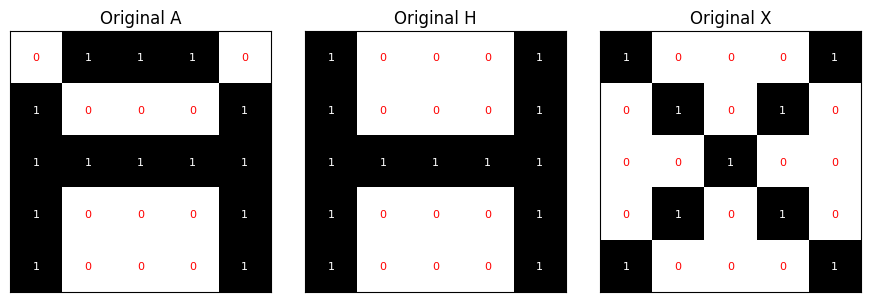

In [3]:
def show_patterns(pattern_list, titles, columns=None):
  count = len(pattern_list)

  if columns is None:
    columns = count

  rows = int(np.ceil(count / columns))

  figure, axes = plt.subplots(
      rows,
      columns,
      figsize=(3 * columns,3 * rows)  
   )
  
  axes = np.array(axes).reshape(-1)

  for axis,pattern,title in zip(axes,pattern_list, titles):
    axis.imshow(
        pattern.reshape(5,5),
        cmap="binary",
        vmin=0,
        vmax=1
    )
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])

    for row in range(5):
      for column in range(5):
        axis.text(
            column,
            row,
            str(pattern.reshape(5,5)[row, column]),
            ha="center",
            va="center",
            fontsize=8,
            color="red" if pattern.reshape(5,5)[row, column] == 0 else "white"
        )

  for unused_axis in axes[count:]:
    unused_axis.axis("off")

  plt.tight_layout()
  plt.show()

show_patterns(
    [patterns["A"],patterns["H"],patterns["X"]],
    ["Original A", "Original H","Original X"])

### 4] generate controlled noisy samples

Noise is introduced by flipping a small number of pixels.

For a binary pixel ($x_i$), a flipped value is:
$$x_i^{\text{noisy}} = 1 - x_i$$

The number of flipped pixels is limited to (0), (1), (2), or (3). This keeps the original class recognizable while still creating a meaningful pattern-matching problem.

In [4]:
random_generator = np.random.default_rng(42)

def add_fixed_number_of_flips(pattern, number_of_flips, generator):
    """Return a copy of the pattern with selected pixels flipped."""
    noisy_pattern = pattern.copy()
    
    if number_of_flips == 0:
        return noisy_pattern
        
    positions = generator.choice(len(pattern), size=number_of_flips, replace=False)
    
    noisy_pattern[positions] = 1 - noisy_pattern[positions]
    
    return noisy_pattern

In [5]:
X = []
y = []

samples_per_class = 400

for class_id, name in enumerate(pattern_names):
    original_pattern = patterns[name]
    
    for _ in range(samples_per_class):
        number_of_flips = int(
            random_generator.choice([0, 1, 2, 3],  
                p=[0.20, 0.30, 0.30, 0.20]
            )
        )
        
        noisy_pattern = add_fixed_number_of_flips(
            original_pattern,
            number_of_flips,
            random_generator
        )
        
        X.append(noisy_pattern)
        y.append(class_id)

X = np.array(X)
y = np.array(y)

print("Training samples:", X.shape[0])
print("Input features :", X.shape[1])
print("Classes        :", pattern_names)

Training samples: 1200
Input features : 25
Classes        : ['A', 'H', 'X']


### 5] RBM concept

An RBM has a visible layer ($\mathbf{v}$) and a hidden layer ($\mathbf{h}$).

The hidden-unit activation probability is:

$$P(h_j = 1 \mid \mathbf{v}) = \sigma \left( b_j + \sum_{i} v_i w_{ij} \right)$$

The visible-unit reconstruction probability is:

$$P(v_i = 1 \mid \mathbf{h}) = \sigma \left( a_i + \sum_{j} h_j w_{ij} \right)$$

The sigmoid activation function is:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

where:

* $v_i$ is visible unit ($i$);
* $h_j$ is hidden unit ($j$);
* $w_{ij}$ is the weight between visible unit ($i$) and hidden unit ($j$);
* $a_i$ is a visible bias;
* $b_j$ is a hidden bias.


### 6] train the RBM


The RBM learns a compact hidden representation of the noisy binary patterns.

In [6]:
from sklearn.neural_network import BernoulliRBM

rbm = BernoulliRBM(
    n_components=16,
    learning_rate=0.05,
    batch_size=20,
    n_iter=60,
    random_state=42,
    verbose=False
)

rbm.fit(X)

print("RBM training completed.")
print("Visible units:", X.shape[1])
print("Hidden units :", rbm.n_components)


RBM training completed.
Visible units: 25
Hidden units : 16


### 7] create a controlled noisy pattern A


The original version used completely random noise. Some random flips changed the pixels that distinguish **A** from **H**.

This revised example flips only two internal pixels. The noisy pattern remains visually recognizable as **A**.


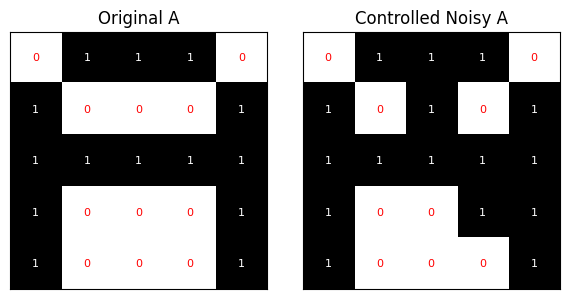

Flipped positions: [7, 18]


In [7]:
original_A = patterns["A"].copy()

# Fixed positions make the example reproducible.
# Pixel positions 7 and 18 are changed.

noisy_A = original_A.copy()
flipped_positions_A = [7, 18]
noisy_A[flipped_positions_A] = 1 - noisy_A[flipped_positions_A]

show_patterns(
    [original_A, noisy_A],
    ["Original A", "Controlled Noisy A"]
)

print("Flipped positions:", flipped_positions_A)


### 8] 

In [8]:
prototype_matrix = np.vstack(
    [patterns[name] for name in pattern_names])

prototype_hidden_features = rbm.transform(prototype_matrix)

def rbm_pattern_match(trained_rbm, input_pattern):
    """Match a pattern using distances in the RBM hidden space."""
    input_hidden = trained_rbm.transform(
        input_pattern.reshape(1, -1)
    )[0]
    
    distances = np.linalg.norm(
        prototype_hidden_features - input_hidden,
        axis=1
    )
    
    matched_index = int(np.argmin(distances))
    matched_name = pattern_names[matched_index]
    
    return matched_name, distances, input_hidden

rbm_match_name, rbm_distances, hidden_A = rbm_pattern_match(rbm, noisy_A)

print("RBM hidden-space distances")

for name, distance in zip(pattern_names, rbm_distances):
    print(f"Distance to {name}: {distance:.4f}")
    
print("\nRBM matched pattern:", rbm_match_name)


RBM hidden-space distances
Distance to A: 0.4483
Distance to H: 1.0587
Distance to X: 2.6753

RBM matched pattern: A


### 9] display the RBM matching result

The matched clean prototype is displayed as the recovered pattern.

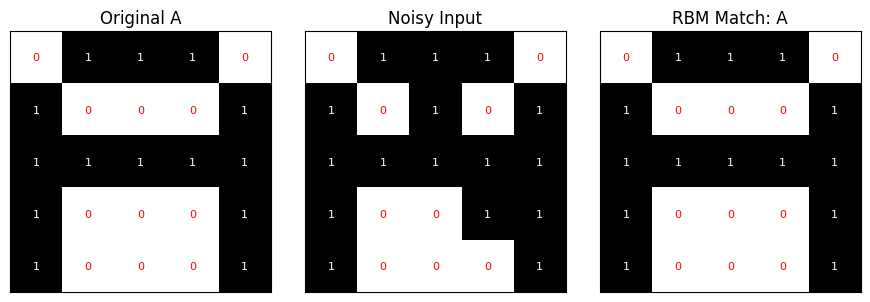

Result verified: noisy A was correctly matched with A.


In [10]:
matched_prototype = patterns[rbm_match_name]

show_patterns(
    [original_A, noisy_A, matched_prototype],
    [
        "Original A",
        "Noisy Input",
        f"RBM Match: {rbm_match_name}"
    ]
)

if rbm_match_name == "A":
    print("Result verified: noisy A was correctly matched with A.")
else:
    print("The RBM did not match the expected pattern.")


### 10] hamming-distance verification

Hamming distance counts the number of different pixels between two binary patterns.

$$d_H(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^{m} \mathbb{1}(x_i \neq y_i)$$

A smaller Hamming distance indicates a closer binary match.

In [13]:
print("Hamming distance of noisy A from each clean pattern:\n")

for name, prototype in patterns.items():
    distance = int(np.sum(noisy_A != prototype))
    print(f"Noisy A to {name}: {distance}")

print("\nThe noisy input is closest to A in both pixel space and the learned RBM hidden space.")

Hamming distance of noisy A from each clean pattern:

Noisy A to A: 2
Noisy A to H: 7
Noisy A to X: 17

The noisy input is closest to A in both pixel space and the learned RBM hidden space.


### 11] simple DBN architecture


A simple DBN is formed by stacking two RBMs:

$$\mathbf{x} \longrightarrow \text{RBM}_1 \longrightarrow \text{RBM}_2 \longrightarrow \text{Classifier}$$

The first RBM learns lower-level pixel relationships.

The second RBM learns higher-level features from the first RBM.

A logistic-regression classifier predicts the final pattern class.


In [14]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

rbm_1 = BernoulliRBM(
    n_components=20,
    learning_rate=0.05,
    batch_size=20,
    n_iter=60,
    random_state=42,
    verbose=False
)

rbm_2 = BernoulliRBM(
    n_components=12,
    learning_rate=0.05,
    batch_size=20,
    n_iter=60,
    random_state=42,
    verbose=False
)

# Greedy Layer-wise pretraining
train_features_1 = rbm_1.fit_transform(X_train)
train_features_2 = rbm_2.fit_transform(train_features_1)

classifier = LogisticRegression( max_iter=1500, random_state=42)

classifier.fit(train_features_2, y_train)

print("DBN training completed.")
print("Input units          :", X_train.shape[1])
print("RBM 1 hidden units   :", rbm_1.n_components)
print("RBM 2 hidden units   :", rbm_2.n_components)

DBN training completed.
Input units          : 25
RBM 1 hidden units   : 20
RBM 2 hidden units   : 12


### 12] evaluate the DBN 

In [15]:
test_features_1 = rbm_1.transform(X_test)
test_features_2 = rbm_2.transform(test_features_1)

predicted_classes = classifier.predict(test_features_2)

test_accuracy = accuracy_score(y_test, predicted_classes)
confusion = confusion_matrix(y_test, predicted_classes)

print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print("\nConfusion matrix:")
print(confusion)

Test accuracy: 99.67%

Confusion matrix:
[[ 99   1   0]
 [  0 100   0]
 [  0   0 100]]


### 13] test the DBN on noise pattern

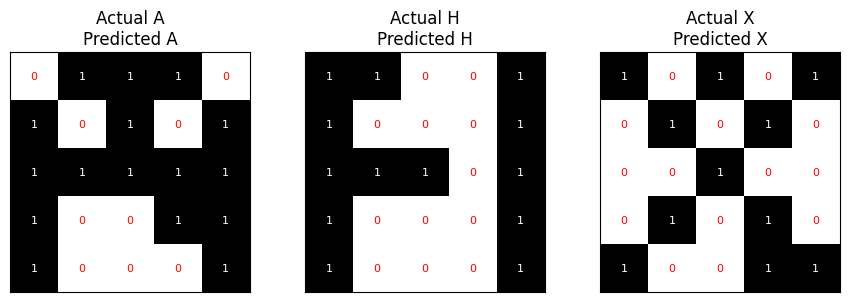

In [19]:
controlled_flips = {
    "A": [7, 18],
    "H": [1, 13],
    "X": [2, 23]
}

test_patterns = []
test_titles = []
prediction_rows = []

for actual_name in pattern_names:
    noisy_pattern = patterns[actual_name].copy()
    positions = controlled_flips[actual_name]
    noisy_pattern[positions] = 1 - noisy_pattern[positions]
    
    level_1_features = rbm_1.transform(
        noisy_pattern.reshape(1, -1)
    )
    
    level_2_features = rbm_2.transform(level_1_features)
    
    predicted_id = int(classifier.predict(level_2_features)[0])
    predicted_name = id_to_class[predicted_id]
    
    probabilities = classifier.predict_proba(level_2_features)[0]
    confidence = float(np.max(probabilities))
    
    test_patterns.append(noisy_pattern)
    test_titles.append(
        f"Actual {actual_name}\nPredicted {predicted_name}"
    )

show_patterns(test_patterns, test_titles)

for actual_name, predicted_name, confidence in prediction_rows:
    print(
        f"Actual: {actual_name} | "
        f"Predicted: {predicted_name} | "
        f"Classifier probability: {confidence:.3f}"
    )

***